# Notebook 03 — Model Training, Ablation & Results

**Project**: Interest-Driven Personalized Sports Recommendation System  
**Purpose**: Train baselines, tuned models, and stacking ensemble; run ablation studies; produce results tables.  
**Constraint**: Classical ML only — no deep learning.

## Models Compared
| ID | Model | Features Used |
|----|-------|---------------|
| B1 | Random | — |
| B2 | Popularity | — (global rates) |
| B3 | Physical-only (XGBoost) | Physical only |
| B4 | Interest-only (XGBoost) | Interests only |
| B5 | Full XGBoost | All features |
| B6 | Full Random Forest | All features |
| **T1** | **Tuned XGBoost (GridSearchCV)** | **All features** |
| **T2** | **Tuned Random Forest (GridSearchCV)** | **All features** |
| **S1** | **Stacking Ensemble (XGB+RF→LR)** | **All features** |
| **S2** | **Stacking + Discovery** | **All features + Discovery Score** |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.preprocessor import SportsPreprocessor, CONTINUOUS_COLS, ORDINAL_COLS, CATEGORICAL_COLS
from src.data.synthetic_generator import SPORTS, INTEREST_DIMS, STRENGTH_DIMS
from src.models.baselines import (RandomBaseline, PopularityBaseline,
                                   PhysicalOnlyModel, InterestOnlyModel,
                                   FullXGBoost, FullRandomForest,
                                   TunedXGBoost, TunedRandomForest,
                                   StackingEnsemble)
from src.features.discovery_score import DiscoveryScorer
from src.evaluation.metrics import evaluate_all

sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('../results', exist_ok=True)
os.makedirs('../experiments', exist_ok=True)
print('Imports OK')

Imports OK


## 1. Load & Preprocess Data

In [2]:
prep = SportsPreprocessor()
splits = prep.fit_transform('../data/processed/synthetic_dataset.csv')
prep.save('../experiments/preprocessor.pkl')

X_train = splits['X_train']
X_test  = splits['X_test']
yp_train, yp_test   = splits['y_play_train'],  splits['y_play_test']
yw_train, yw_test   = splits['y_watch_train'],  splits['y_watch_test']
ypr_train, ypr_test = splits['y_pro_train'],    splits['y_pro_test']
feat_names = splits['feature_names']

# Feature group indices
interest_idx  = [feat_names.index(f'interest_{d}') for d in INTEREST_DIMS if f'interest_{d}' in feat_names]
strength_idx  = [feat_names.index(f'strength_{d}') for d in STRENGTH_DIMS if f'strength_{d}' in feat_names]
physical_idx  = [feat_names.index(c) for c in CONTINUOUS_COLS if c in feat_names]
n_features    = X_train.shape[1]
n_sports      = yp_train.shape[1]

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Features: {n_features}  Sports: {n_sports}')
print(f'Interest dims: {len(interest_idx)}  Physical dims: {len(physical_idx)}')

Preprocessor saved to ../experiments/preprocessor.pkl
Train: (800, 29)  Test: (200, 29)
Features: 29  Sports: 20
Interest dims: 12  Physical dims: 6


## 2. Train All Baselines

In [3]:
print('Training baselines...')

b1 = RandomBaseline().fit(X_train, yp_train)
b2 = PopularityBaseline().fit(X_train, yp_train)
b3 = PhysicalOnlyModel(physical_idx).fit(X_train, yp_train)
b4 = InterestOnlyModel(interest_idx).fit(X_train, yp_train)
b5 = FullXGBoost().fit(X_train, yp_train)
b6 = FullRandomForest().fit(X_train, yp_train)

print('All baselines trained.')

Training baselines...


All baselines trained.


## 3. Hyperparameter Tuning & Stacking Ensemble

In [4]:
print('Training Tuned XGBoost (GridSearchCV)...')
t1 = TunedXGBoost(cv=3, verbose=1).fit(X_train, yp_train)
print(f'\nTraining Tuned Random Forest (GridSearchCV)...')
t2 = TunedRandomForest(cv=3, verbose=1).fit(X_train, yp_train)
print(f'\nTraining Stacking Ensemble (XGB+RF → LogisticRegression)...')
s1 = StackingEnsemble(cv=3).fit(X_train, yp_train)
print('All improved models trained.')

Training Tuned XGBoost (GridSearchCV)...
Fitting 3 folds for each of 243 candidates, totalling 729 fits


  Best XGB params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}



Training Tuned Random Forest (GridSearchCV)...
Fitting 3 folds for each of 108 candidates, totalling 324 fits


  Best RF params: {'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 300}



Training Stacking Ensemble (XGB+RF → LogisticRegression)...


All improved models trained.


## 4. Fit Discovery Score Module

In [5]:
disc = DiscoveryScorer(alpha=0.4)
disc.fit(X_train, interest_idx, yp_train)

# Blended scores: Stacking ensemble play scores + discovery
stack_play_scores = s1.predict_scores(X_test)
blended_scores = disc.blend(stack_play_scores, X_test, interest_idx, tried_mask=yp_test)

print('Discovery scorer fitted.')
print(f'Sample top-5 discoveries for user 0:')
tops = disc.top_k_discoveries(X_test[:5], interest_idx, yp_test[:5], SPORTS, k=5)
for i, recs in enumerate(tops):
    print(f'  User {i}: {recs}')

Discovery scorer fitted.
Sample top-5 discoveries for user 0:
  User 0: ['rowing', 'badminton', 'gymnastics', 'rugby', 'boxing']
  User 1: ['weightlifting', 'cycling', 'athletics_track', 'volleyball', 'basketball']
  User 2: ['swimming', 'table_tennis', 'martial_arts', 'rowing', 'esports']
  User 3: ['archery', 'rock_climbing', 'table_tennis', 'weightlifting', 'swimming']
  User 4: ['archery', 'rock_climbing', 'cycling', 'cricket', 'athletics_track']


## 5. Evaluate All Models — Play Task

In [6]:
KS = [5, 10]
models_play = {
    'B1_Random':        b1.predict_scores(X_test),
    'B2_Popularity':    b2.predict_scores(X_test),
    'B3_PhysicalOnly':  b3.predict_scores(X_test),
    'B4_InterestOnly':  b4.predict_scores(X_test),
    'B5_FullXGBoost':   b5.predict_scores(X_test),
    'B6_FullRF':        b6.predict_scores(X_test),
    'T1_TunedXGB':      t1.predict_scores(X_test),
    'T2_TunedRF':       t2.predict_scores(X_test),
    'S1_Stacking':      s1.predict_scores(X_test),
    'S2_Stack+Disc':    blended_scores,
}

results_play = {}
for name, scores in models_play.items():
    results_play[name] = evaluate_all(yp_test, scores, tried_mask=yp_test,
                                       ks=KS, label=name)

df_play = pd.DataFrame(results_play).T
df_play.to_csv('../results/play_results.csv')
print('\nPlay Task Results:')
print(df_play[['precision@5','recall@5','f1@5','ndcg@5','map@5','discovery_rate@5']].round(4))


  B1_RANDOM METRICS
  precision@5              : 0.2010
  recall@5                 : 0.2469
  f1@5                     : 0.2216
  ndcg@5                   : 0.2283
  map@5                    : 0.5002
  discovery_rate@5         : 0.7990
  precision@10             : 0.2050
  recall@10                : 0.5157
  f1@10                    : 0.2934
  ndcg@10                  : 0.3435
  map@10                   : 0.3782
  discovery_rate@10        : 0.7950

  B2_POPULARITY METRICS
  precision@5              : 0.3800
  recall@5                 : 0.4869
  f1@5                     : 0.4269
  ndcg@5                   : 0.5016
  map@5                    : 0.7149
  discovery_rate@5         : 0.6200
  precision@10             : 0.2775
  recall@10                : 0.7122
  f1@10                    : 0.3994
  ndcg@10                  : 0.5848
  map@10                   : 0.6163
  discovery_rate@10        : 0.7225

  B3_PHYSICALONLY METRICS
  precision@5              : 0.3350
  recall@5                 

## 6. Evaluate — Watch Task

In [7]:
# Train watch-task models
b2_watch = PopularityBaseline().fit(X_train, yw_train)
b5_watch = FullXGBoost().fit(X_train, yw_train)
s1_watch = StackingEnsemble(cv=3).fit(X_train, yw_train)

models_watch = {
    'B1_Random':       b1.predict_scores(X_test),
    'B2_Popularity':   b2_watch.predict_scores(X_test),
    'B5_FullXGBoost':  b5_watch.predict_scores(X_test),
    'S1_Stacking':     s1_watch.predict_scores(X_test),
}

results_watch = {}
for name, scores in models_watch.items():
    results_watch[name] = evaluate_all(yw_test, scores, ks=KS, label=name)

df_watch = pd.DataFrame(results_watch).T
df_watch.to_csv('../results/watch_results.csv')
print('\nWatch Task Results:')
print(df_watch[['precision@5','recall@5','ndcg@5','map@5']].round(4))


  B1_RANDOM METRICS
  precision@5              : 0.5550
  recall@5                 : 0.2673
  f1@5                     : 0.3608
  ndcg@5                   : 0.5607
  map@5                    : 0.7160
  precision@10             : 0.5360
  recall@10                : 0.5117
  f1@10                    : 0.5236
  ndcg@10                  : 0.5737
  map@10                   : 0.6543

  B2_POPULARITY METRICS
  precision@5              : 0.7240
  recall@5                 : 0.3522
  f1@5                     : 0.4738
  ndcg@5                   : 0.7412
  map@5                    : 0.8511
  precision@10             : 0.6395
  recall@10                : 0.6193
  f1@10                    : 0.6292
  ndcg@10                  : 0.7157
  map@10                   : 0.7895

  B5_FULLXGBOOST METRICS
  precision@5              : 0.6560
  recall@5                 : 0.3149
  f1@5                     : 0.4256
  ndcg@5                   : 0.6768
  map@5                    : 0.8138
  precision@10             :

## 7. Ablation Study

In [8]:
ablation = {
    'Physical-only':   b3.predict_scores(X_test),
    'Interest-only':   b4.predict_scores(X_test),
    'Full XGBoost':    b5.predict_scores(X_test),
    'Full RF':         b6.predict_scores(X_test),
    'Tuned XGBoost':   t1.predict_scores(X_test),
    'Tuned RF':        t2.predict_scores(X_test),
    'Stacking':        s1.predict_scores(X_test),
    'Stack+Discovery': blended_scores,
}

ablation_results = {}
for name, scores in ablation.items():
    ablation_results[name] = evaluate_all(yp_test, scores, tried_mask=yp_test, ks=[5, 10])

df_ablation = pd.DataFrame(ablation_results).T
df_ablation.to_csv('../results/ablation_results.csv')
print('Ablation Results:')
print(df_ablation[['precision@5','ndcg@5','map@5','discovery_rate@5']].round(4))

Ablation Results:
                 precision@5  ndcg@5   map@5  discovery_rate@5
Physical-only          0.335  0.4243  0.6851             0.665
Interest-only          0.321  0.4058  0.6289             0.679
Full XGBoost           0.332  0.4291  0.6777             0.668
Full RF                0.372  0.4911  0.7083             0.628
Tuned XGBoost          0.317  0.4125  0.6765             0.683
Tuned RF               0.371  0.4934  0.7254             0.629
Stacking               0.381  0.4977  0.7049             0.619
Stack+Discovery        0.143  0.2028  0.6389             0.857


## 8. Results Visualisation

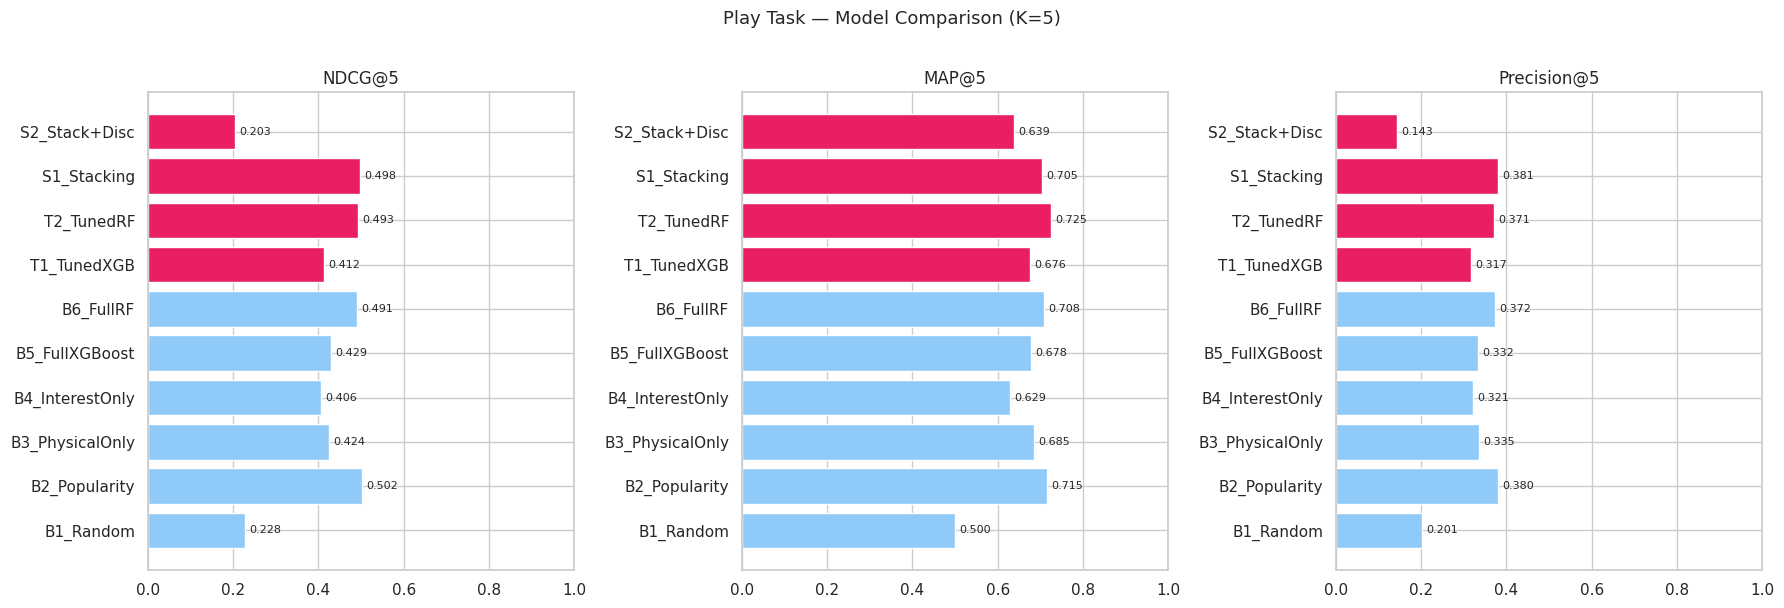

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['ndcg@5', 'map@5', 'precision@5']
titles = ['NDCG@5', 'MAP@5', 'Precision@5']
colors = ['#E91E63' if ('Tuned' in n or 'Stack' in n or 'Disc' in n) else '#90CAF9' for n in df_play.index]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    vals = df_play[metric]
    bars = ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Play Task — Model Comparison (K=5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/model_comparison_play.png', dpi=150, bbox_inches='tight')
plt.show()

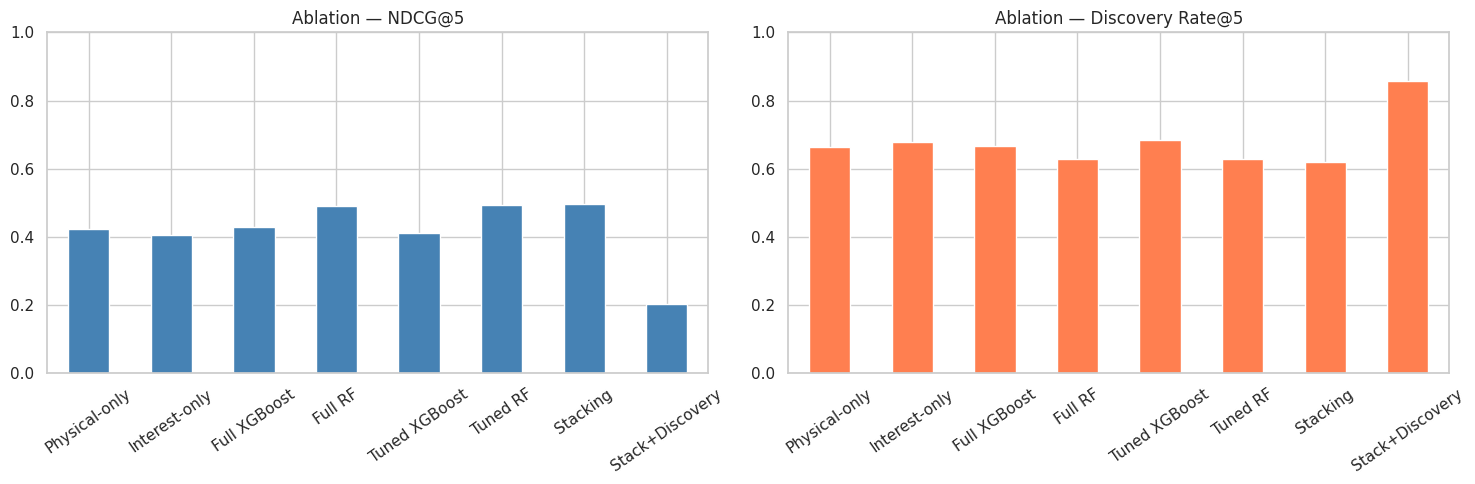

In [10]:
# Ablation bar chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_ablation['ndcg@5'].plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ablation — NDCG@5'); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=35)

df_ablation['discovery_rate@5'].plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Ablation — Discovery Rate@5'); axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('../results/ablation_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Group Importance (Gini + Permutation)

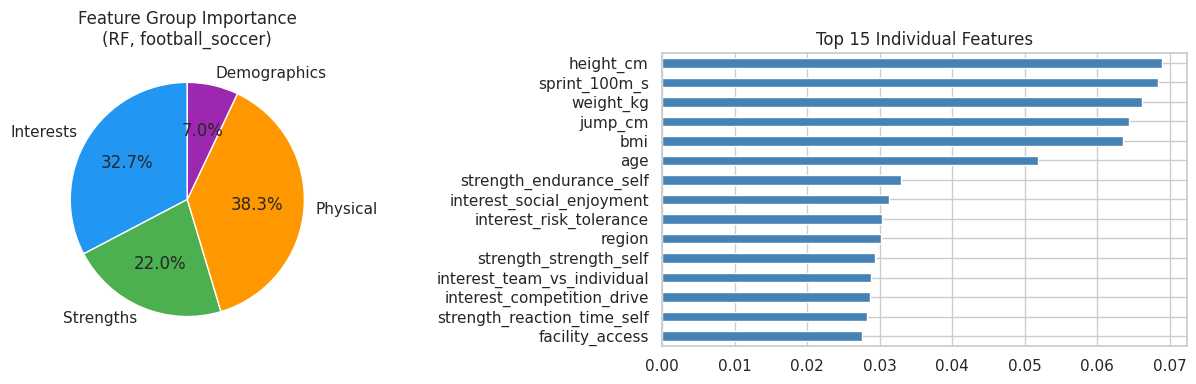


Feature group contributions:
Interests       0.3269
Strengths       0.2195
Physical        0.3831
Demographics    0.0704
dtype: float64

Interest features account for 32.7% of importance
Target >50%: FAIL ❌ (check affinity weights)


In [11]:
from sklearn.inspection import permutation_importance
from sklearn.multioutput import MultiOutputClassifier

# Use a single-output RF on the most popular sport for fast SHAP proxy
from sklearn.ensemble import RandomForestClassifier

sport_idx = 0  # football_soccer
rf_single = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_single.fit(X_train, yp_train[:, sport_idx])

importances = rf_single.feature_importances_
feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

# Group by feature type
interest_imp = feat_imp[[f for f in feat_imp.index if 'interest_' in f]].sum()
strength_imp = feat_imp[[f for f in feat_imp.index if 'strength_' in f]].sum()
physical_imp = feat_imp[[f for f in feat_imp.index if f in CONTINUOUS_COLS]].sum()
demog_imp    = feat_imp[[f for f in feat_imp.index if f in CATEGORICAL_COLS + ['facility_access']]].sum()

group_imp = pd.Series({
    'Interests':     interest_imp,
    'Strengths':     strength_imp,
    'Physical':      physical_imp,
    'Demographics':  demog_imp,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

group_imp.plot.pie(ax=axes[0], autopct='%1.1f%%', colors=['#2196F3','#4CAF50','#FF9800','#9C27B0'],
                   startangle=90)
axes[0].set_title(f'Feature Group Importance\n(RF, football_soccer)')
axes[0].set_ylabel('')

feat_imp.head(15).plot.barh(ax=axes[1], color='steelblue')
axes[1].set_title('Top 15 Individual Features'); axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFeature group contributions:")
print(group_imp.round(4))
print(f"\nInterest features account for {group_imp['Interests']/group_imp.sum()*100:.1f}% of importance")
target_met = group_imp['Interests'] / group_imp.sum() > 0.50
print(f"Target >50%: {'PASS ✅' if target_met else 'FAIL ❌ (check affinity weights)'}")

## 10. Final Summary Table

In [12]:
summary_cols = ['precision@5', 'recall@5', 'f1@5', 'ndcg@5', 'map@5', 'discovery_rate@5']
print('='*75)
print('FINAL RESULTS TABLE — PLAY TASK (K=5)')
print('='*75)
print(df_play[summary_cols].round(4).to_string())
print()

# Compute improvement of best classical model over physical-only baseline (B3)
best_model = df_play.loc[~df_play.index.str.contains('Disc|Random|Pop'), 'ndcg@5'].idxmax()
best_ndcg = df_play.loc[best_model, 'ndcg@5']
phys_ndcg = df_play.loc['B3_PhysicalOnly', 'ndcg@5']
base_xgb_ndcg = df_play.loc['B5_FullXGBoost', 'ndcg@5']
improvement_phys = (best_ndcg - phys_ndcg) / (phys_ndcg + 1e-8) * 100
improvement_xgb  = (best_ndcg - base_xgb_ndcg) / (base_xgb_ndcg + 1e-8) * 100

print(f'Best classical model: {best_model} (NDCG@5 = {best_ndcg:.4f})')
print(f'  vs Physical-only  (B3): +{improvement_phys:.1f}%')
print(f'  vs Base XGBoost   (B5): +{improvement_xgb:.1f}%')

df_play[summary_cols].round(4).to_csv('../results/final_summary_table.csv')
print('\nResults saved to results/final_summary_table.csv')

FINAL RESULTS TABLE — PLAY TASK (K=5)
                 precision@5  recall@5    f1@5  ndcg@5   map@5  discovery_rate@5
B1_Random              0.201    0.2469  0.2216  0.2283  0.5002             0.799
B2_Popularity          0.380    0.4869  0.4269  0.5016  0.7149             0.620
B3_PhysicalOnly        0.335    0.4149  0.3707  0.4243  0.6851             0.665
B4_InterestOnly        0.321    0.4188  0.3634  0.4058  0.6289             0.679
B5_FullXGBoost         0.332    0.4217  0.3715  0.4291  0.6777             0.668
B6_FullRF              0.372    0.4784  0.4185  0.4911  0.7083             0.628
T1_TunedXGB            0.317    0.4011  0.3541  0.4125  0.6765             0.683
T2_TunedRF             0.371    0.4757  0.4169  0.4934  0.7254             0.629
S1_Stacking            0.381    0.4865  0.4273  0.4977  0.7049             0.619
S2_Stack+Disc          0.143    0.1793  0.1591  0.2028  0.6389             0.857

Best classical model: S1_Stacking (NDCG@5 = 0.4977)
  vs Physical-only